## **Smart Agriculture for Precision Livestock Monitoring and Management**

**LEVEL-1**

**DAY-1 Data Preprocessing and Random Forest Model Implementation**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving livestock_monitoring_dataset.csv to livestock_monitoring_dataset.csv


In [ ]:
# @title
df = pd.read_csv("livestock_monitoring_dataset.csv")

df.head()

,animal_id,record_date,species,breed,age_months,sex,weight_kg,body_temperature_c,heart_rate_bpm,respiration_rate_bpm,...,water_intake_l,milk_yield_l,days_since_calving,ambient_temperature_c,humidity_pct,vaccination_status,previous_illness_count,gps_movement_zone,calving_event_predicted,health_status
0,LVS100000,2024-09-16,Cattle,Gir,123,Female,215.4,38.25,48.0,33.2,...,52.7,13.53,1,38.4,76.1,Up-to-date,1,Grazing Area,No,At Risk
1,LVS100001,2025-01-14,Cattle,Crossbred,89,Female,405.0,39.18,79.7,19.8,...,67.2,14.91,106,39.6,45.3,Up-to-date,1,Water Point,No,Sick/Distress
2,LVS100002,2025-03-20,Buffalo,Murrah Buffalo,138,Female,359.6,38.74,71.5,21.1,...,40.8,19.18,120,26.7,55.5,Up-to-date,1,Grazing Area,No,At Risk
3,LVS100003,2025-03-25,Cattle,Sahiwal,95,Female,373.6,37.62,60.1,31.8,...,39.7,21.21,32,32.6,38.5,Up-to-date,0,Water Point,No,Healthy
4,LVS100004,2024-12-14,Cattle,Holstein,126,Female,358.6,39.83,51.9,32.1,...,59.4,20.48,241,34.8,NaN,Up-to-date,1,Milking Parlor,No,Sick/Distress


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   animal_id                12000 non-null  object 
 1   record_date              12000 non-null  object 
 2   species                  12000 non-null  object 
 3   breed                    12000 non-null  object 
 4   age_months               12000 non-null  int64  
 5   sex                      12000 non-null  object 
 6   weight_kg                11820 non-null  float64
 7   body_temperature_c       12000 non-null  float64
 8   heart_rate_bpm           12000 non-null  float64
 9   respiration_rate_bpm     12000 non-null  float64
 10  rumination_time_min      12000 non-null  float64
 11  activity_level_steps     12000 non-null  float64
 12  lying_time_hours         12000 non-null  float64
 13  feed_intake_kg           12000 non-null  float64
 14  water_intake_l        

In [ ]:
df.shape

(12000, 24)

In [ ]:
df.describe()

,age_months,weight_kg,body_temperature_c,heart_rate_bpm,respiration_rate_bpm,rumination_time_min,activity_level_steps,lying_time_hours,feed_intake_kg,water_intake_l,milk_yield_l,days_since_calving,ambient_temperature_c,humidity_pct,previous_illness_count
count,12000.000000,11820.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11820.000000,11820.000000,12000.000000,12000.000000,11820.000000,12000.000000
mean,74.831333,419.590761,38.599987,64.824483,28.015608,480.653950,3498.864917,10.471278,13.996212,60.084619,18.036772,128.478500,28.956525,65.054763,0.601083
std,39.816253,90.968342,0.494107,9.993652,6.017594,59.792394,898.495449,2.011672,2.968048,15.046180,6.035483,97.404985,5.967554,14.872127,0.772117
min,6.000000,80.000000,36.760000,27.600000,3.400000,241.800000,200.000000,2.860000,2.760000,10.000000,0.000000,-1.000000,6.900000,12.500000,0.000000
25%,41.000000,359.000000,38.270000,58.100000,23.900000,440.600000,2902.000000,9.110000,11.990000,49.900000,14.030000,36.000000,24.900000,55.100000,0.000000
50%,75.000000,419.400000,38.600000,64.900000,28.000000,480.050000,3503.500000,10.480000,13.965000,60.300000,18.050000,125.000000,29.000000,64.900000,0.000000
75%,109.000000,480.700000,38.930000,71.500000,32.100000,521.100000,4104.000000,11.810000,16.020000,70.200000,22.040000,215.000000,33.000000,75.100000,1.000000
max,143.000000,741.700000,40.380000,101.800000,50.700000,714.000000,6668.000000,18.000000,25.090000,121.200000,41.320000,304.000000,45.000000,100.000000,6.000000


In [ ]:
df.isnull().sum()

,0
animal_id,0
record_date,0
species,0
breed,0
age_months,0
sex,0
weight_kg,180
body_temperature_c,0
heart_rate_bpm,0
respiration_rate_bpm,0


In [ ]:
df['health_status'].value_counts()

,count
health_status,
At Risk,4633
Sick/Distress,4000
Healthy,3367


In [ ]:
df = df.drop(['animal_id','record_date'],axis=1, errors='ignore')

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('health_status',axis=1)

y = df['health_status']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.67125


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.59      0.61      0.60       956
           1       0.67      0.66      0.67       653
           2       0.77      0.75      0.76       791

    accuracy                           0.67      2400
   macro avg       0.68      0.67      0.68      2400
weighted avg       0.67      0.67      0.67      2400



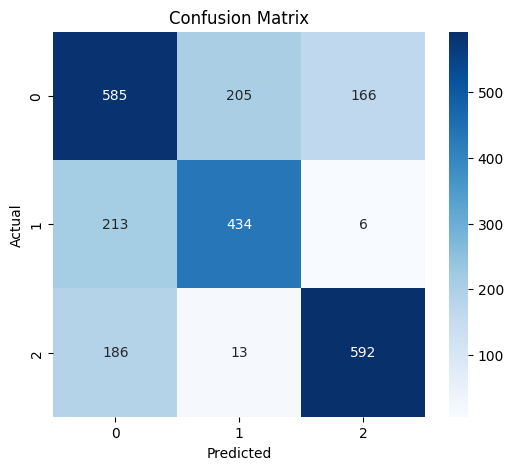

In [ ]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(by="Importance",ascending=False)

importance

,Feature,Importance
5,body_temperature_c,0.182638
8,rumination_time_min,0.110107
9,activity_level_steps,0.086913
6,heart_rate_bpm,0.072771
12,water_intake_l,0.047636
4,weight_kg,0.047551
13,milk_yield_l,0.046596
16,humidity_pct,0.046359
11,feed_intake_kg,0.043784
10,lying_time_hours,0.043260


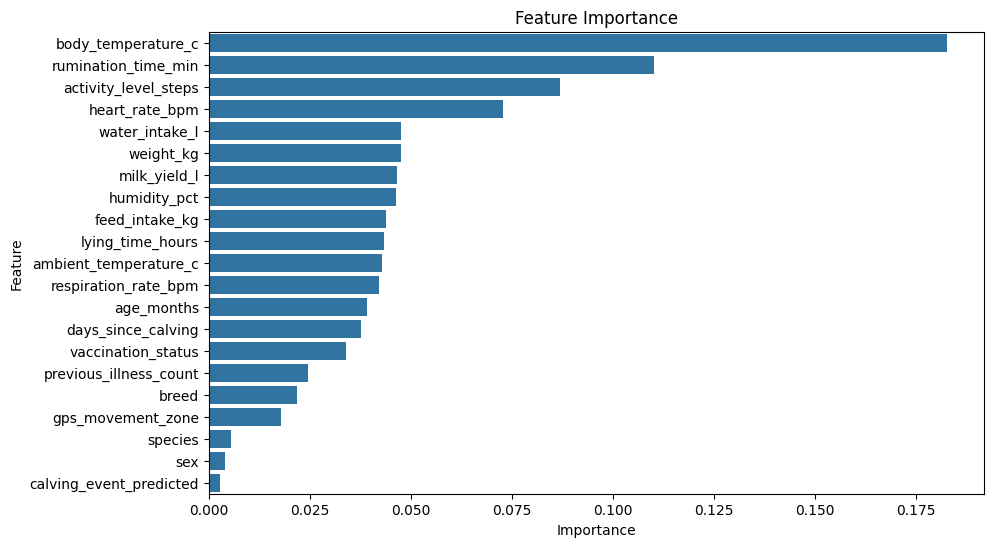

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

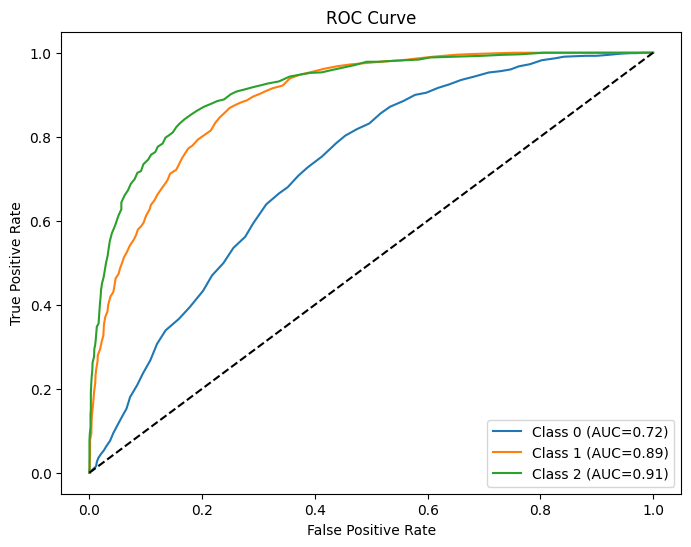

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
import joblib

joblib.dump(model,"livestock_health_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:",prediction)

Prediction: [1]


**DAY-2 Gradient Boosting and Hyperparameter Tuning**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)

# Identify columns with missing values
missing_cols = X_train.columns[X_train.isnull().any()].tolist()

# Impute missing values with the median for both training and test sets
for col in missing_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
gb_pred = gb_model.predict(X_test)

In [ ]:
gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy :", gb_accuracy)

Gradient Boosting Accuracy : 0.685


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.61      0.64      0.63       956
           1       0.68      0.69      0.68       653
           2       0.80      0.73      0.76       791

    accuracy                           0.69      2400
   macro avg       0.70      0.69      0.69      2400
weighted avg       0.69      0.69      0.69      2400



In [ ]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

In [ ]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
print("Best Cross Validation Accuracy:")
print(grid.best_score_)

Best Cross Validation Accuracy:
0.6782291666666667


In [ ]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Test Accuracy :",
      accuracy_score(y_test,best_pred))

Test Accuracy : 0.6758333333333333


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],

    "Accuracy":[
        accuracy,
        gb_accuracy,
        accuracy_score(y_test,best_pred)
    ]

})

comparison

,Model,Accuracy
0,Random Forest,0.671250
1,Gradient Boosting,0.685000
2,Tuned Random Forest,0.675833


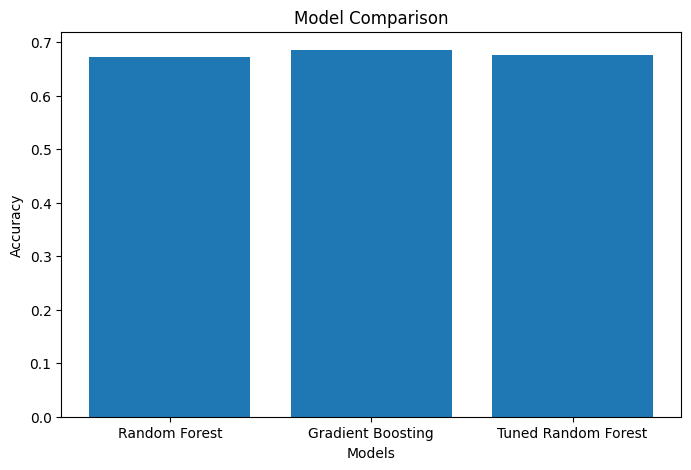

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"],
        comparison["Accuracy"])

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

In [ ]:
import joblib

joblib.dump(best_model,"best_livestock_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


**DAY-3 Artificial Neural Network (ANN) Model Implementation**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3626 - loss: 4.6322 - val_accuracy: 0.3922 - val_loss: 4.0183
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3990 - loss: 2.3298 - val_accuracy: 0.4161 - val_loss: 1.5368
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4012 - loss: 1.9981 - val_accuracy: 0.3849 - val_loss: 2.1696
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4122 - loss: 1.8997 - val_accuracy: 0.4120 - val_loss: 1.4092
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4138 - loss: 1.9724 - val_accuracy: 0.4755 - val_loss: 1.0646
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4142 - loss: 2.0275 - val_accuracy: 0.3906 - val_loss: 2.4617
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4221 - loss: 1.7022 - val_accuracy: 0.4583 - val_loss: 2.2268
Epoch 8/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4348 - loss: 1.5384 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4604 - loss: 1.1192
Test Accuracy : 0.46041667461395264


In [ ]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.42      0.57      0.48       956
           1       0.47      0.72      0.57       653
           2       0.84      0.12      0.21       791

    accuracy                           0.46      2400
   macro avg       0.58      0.47      0.42      2400
weighted avg       0.57      0.46      0.42      2400



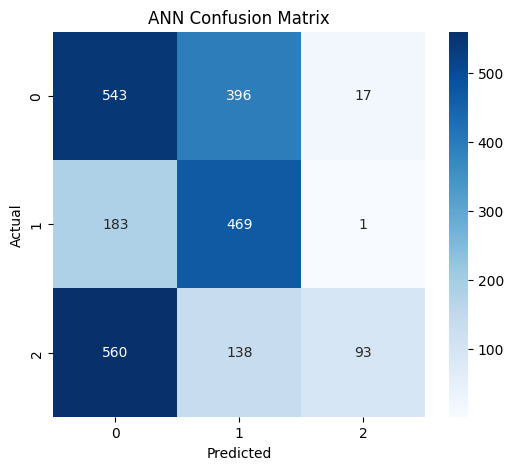

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")

plt.show()

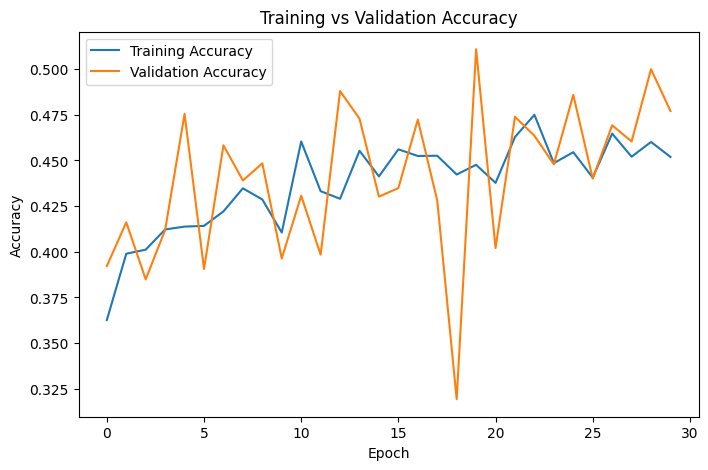

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

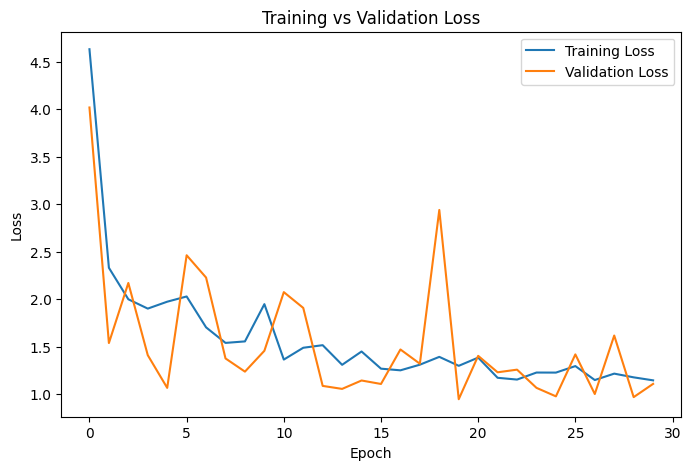

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
model.save("livestock_ann_model.keras")

print("ANN Model Saved Successfully")

ANN Model Saved Successfully


**LEVEL-2**

**DAY 4 – LSTM Model**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("livestock_monitoring_dataset.csv")

In [ ]:
df.head()

,animal_id,record_date,species,breed,age_months,sex,weight_kg,body_temperature_c,heart_rate_bpm,respiration_rate_bpm,...,water_intake_l,milk_yield_l,days_since_calving,ambient_temperature_c,humidity_pct,vaccination_status,previous_illness_count,gps_movement_zone,calving_event_predicted,health_status
0,LVS100000,2024-09-16,Cattle,Gir,123,Female,215.4,38.25,48.0,33.2,...,52.7,13.53,1,38.4,76.1,Up-to-date,1,Grazing Area,No,At Risk
1,LVS100001,2025-01-14,Cattle,Crossbred,89,Female,405.0,39.18,79.7,19.8,...,67.2,14.91,106,39.6,45.3,Up-to-date,1,Water Point,No,Sick/Distress
2,LVS100002,2025-03-20,Buffalo,Murrah Buffalo,138,Female,359.6,38.74,71.5,21.1,...,40.8,19.18,120,26.7,55.5,Up-to-date,1,Grazing Area,No,At Risk
3,LVS100003,2025-03-25,Cattle,Sahiwal,95,Female,373.6,37.62,60.1,31.8,...,39.7,21.21,32,32.6,38.5,Up-to-date,0,Water Point,No,Healthy
4,LVS100004,2024-12-14,Cattle,Holstein,126,Female,358.6,39.83,51.9,32.1,...,59.4,20.48,241,34.8,NaN,Up-to-date,1,Milking Parlor,No,Sick/Distress


In [ ]:
df.isnull().sum()

,0
animal_id,0
record_date,0
species,0
breed,0
age_months,0
sex,0
weight_kg,180
body_temperature_c,0
heart_rate_bpm,0
respiration_rate_bpm,0


In [ ]:
encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = encoder.fit_transform(df[column])

In [ ]:
X = df.drop("health_status", axis=1)

y = df["health_status"]

In [ ]:
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

In [ ]:
X = X.reshape((X.shape[0], X.shape[1],1))

NameError: name 'X' is not defined

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

model.add(LSTM(64, activation="relu", input_shape=(X.shape[1],1)))

model.add(Dense(32, activation="relu"))

model.add(Dense(3, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32
)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3821 - loss: nan
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3830 - loss: nan
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3830 - loss: nan
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3830 - loss: nan
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3830 - loss: nan
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3830 - loss: nan
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3830 - loss: nan
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3830 - loss: nan
Epoch 9/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3830 - loss: nan
Epoch 10/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3830 - loss: nan
Epoch 11/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3830 - loss: nan
Epoch 12/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3830 - loss: 

In [ ]:
prediction = model.predict(X_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
prediction = np.argmax(prediction, axis=1)

In [ ]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.3983333333333333


**DAY 5 – NLP Pipeline**

In [ ]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv("livestock_monitoring_dataset.csv")

In [ ]:
df["text"] = (
    "Species " + df["species"].astype(str) +
    " Breed " + df["breed"].astype(str) +
    " Temperature " + df["body_temperature_c"].astype(str) +
    " HeartRate " + df["heart_rate_bpm"].astype(str) +
    " Feed " + df["feed_intake_kg"].astype(str)
)

In [ ]:
df[["text","health_status"]].head()

,text,health_status
0,Species Cattle Breed Gir Temperature 38.25 Hea...,At Risk
1,Species Cattle Breed Crossbred Temperature 39....,Sick/Distress
2,Species Buffalo Breed Murrah Buffalo Temperatu...,At Risk
3,Species Cattle Breed Sahiwal Temperature 37.62...,Healthy
4,Species Cattle Breed Holstein Temperature 39.8...,Sick/Distress


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9 ]", "", text)
    return text

df["text"] = df["text"].apply(clean_text)

In [ ]:
X = df["text"]
y = df["health_status"]

In [ ]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
prediction = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.4675


In [ ]:
print(classification_report(y_test, prediction))

               precision    recall  f1-score   support

      At Risk       0.44      0.63      0.52       956
      Healthy       0.41      0.26      0.32       653
Sick/Distress       0.56      0.45      0.50       791

     accuracy                           0.47      2400
    macro avg       0.47      0.44      0.44      2400
 weighted avg       0.47      0.47      0.46      2400



**DAY 6 – AI Health Recommendation System (SLM )**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("livestock_monitoring_dataset.csv")

In [ ]:
df.head()

,animal_id,record_date,species,breed,age_months,sex,weight_kg,body_temperature_c,heart_rate_bpm,respiration_rate_bpm,...,water_intake_l,milk_yield_l,days_since_calving,ambient_temperature_c,humidity_pct,vaccination_status,previous_illness_count,gps_movement_zone,calving_event_predicted,health_status
0,LVS100000,2024-09-16,Cattle,Gir,123,Female,215.4,38.25,48.0,33.2,...,52.7,13.53,1,38.4,76.1,Up-to-date,1,Grazing Area,No,At Risk
1,LVS100001,2025-01-14,Cattle,Crossbred,89,Female,405.0,39.18,79.7,19.8,...,67.2,14.91,106,39.6,45.3,Up-to-date,1,Water Point,No,Sick/Distress
2,LVS100002,2025-03-20,Buffalo,Murrah Buffalo,138,Female,359.6,38.74,71.5,21.1,...,40.8,19.18,120,26.7,55.5,Up-to-date,1,Grazing Area,No,At Risk
3,LVS100003,2025-03-25,Cattle,Sahiwal,95,Female,373.6,37.62,60.1,31.8,...,39.7,21.21,32,32.6,38.5,Up-to-date,0,Water Point,No,Healthy
4,LVS100004,2024-12-14,Cattle,Holstein,126,Female,358.6,39.83,51.9,32.1,...,59.4,20.48,241,34.8,NaN,Up-to-date,1,Milking Parlor,No,Sick/Distress


In [ ]:
def health_recommendation(status):

    if status == "Healthy":
        return "Animal is healthy. Continue regular feeding and vaccination."

    elif status == "At Risk":
        return "Monitor the animal closely and consult a veterinarian."

    elif status == "Sick":
        return "Immediate veterinary treatment is recommended."

    else:
        return "No recommendation available."

In [ ]:
df["Recommendation"] = df["health_status"].apply(health_recommendation)

In [ ]:
df[["health_status", "Recommendation"]].head()

,health_status,Recommendation
0,At Risk,Monitor the animal closely and consult a veter...
1,Sick/Distress,No recommendation available.
2,At Risk,Monitor the animal closely and consult a veter...
3,Healthy,Animal is healthy. Continue regular feeding an...
4,Sick/Distress,No recommendation available.


In [ ]:
df.to_csv("livestock_health_recommendation.csv", index=False)

In [ ]:
from google.colab import files

files.download("livestock_health_recommendation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>